In [1]:
%load_ext autoreload
%autoreload 2
from autogluon.timeseries import TimeSeriesDataFrame
import pandas as pd
import numpy as np
from pathlib import Path
from src.data.preprocessor import read_smard_data

In [17]:
def find_safetensors(root):
    root = Path(root)
    return [p for p in root.rglob("*.safetensors") if p.is_file()]

# example
for path in find_safetensors("/Users/louisskowronek/Documents/thesis/master-thesis/results"):
    path.unlink()

# Read data

In [2]:
data, mapping = read_smard_data(
    file_paths=[
        "data/electricity_consumption/Actual_consumption_201501010000_202001010000_Quarterhour.csv",
        "data/electricity_consumption/Actual_consumption_202001010000_202509010000_Quarterhour.csv",
    ],
    selected_time_series=["grid load [MWh] Original resolutions", "Residual load [MWh] Original resolutions"],
    freq=pd.Timedelta("15 min"),
)

2025-09-30 02:30:42,810 - INFO - preprocessor.py - Reading SMARD data...
2025-09-30 02:30:42,810 - INFO - preprocessor.py - Reading file: data/electricity_consumption/Actual_consumption_201501010000_202001010000_Quarterhour.csv
2025-09-30 02:30:43,473 - INFO - preprocessor.py - Reading file: data/electricity_consumption/Actual_consumption_202001010000_202509010000_Quarterhour.csv
2025-09-30 02:30:44,215 - INFO - preprocessor.py - Total rows after concat: 374012
2025-09-30 02:30:44,216 - INFO - preprocessor.py - Filtering columns: ['grid load [MWh] Original resolutions', 'Residual load [MWh] Original resolutions']
2025-09-30 02:30:44,218 - INFO - preprocessor.py - Columns retained: ['End date', 'grid load [MWh] Original resolutions', 'Residual load [MWh] Original resolutions']
2025-09-30 02:30:44,242 - INFO - preprocessor.py - Reshaped DataFrame: 747922 rows
2025-09-30 02:30:44,278 - INFO - preprocessor.py - Mapped 2 unique time series.
2025-09-30 02:30:44,325 - INFO - preprocessor.py -

# Predictions

In [3]:
# set frequency and quantiles
lead_times = np.arange(1, 192+1).tolist()
quantiles = np.arange(0.1,1,0.1).round(1).tolist()
freq = pd.DateOffset(minutes=15)

## Minimum working example

In [4]:
from src.postprocessors.mle import PostprocessorMLE
from src.postprocessors.qr import PostprocessorFastQR
from src.postprocessors.eqc import PostprocessorEQC
from src.pipeline.pipeline import ForecastingPipeline
from src.predictors.chronos import Chronos

2025-09-30 02:30:55,725 - INFO - config.py - PyTorch version 2.5.1 available.


In [9]:
pipeline = ForecastingPipeline(
    model=Chronos,
    model_kwargs={
        "pretrained_model_name_or_path": f"amazon/chronos-bolt-tiny",
        "device_map": "mps",
        "lead_times": lead_times,
        "name": f"Chronos-Bolt-tiny",
    },
    postprocessors=[PostprocessorFastQR, PostprocessorEQC],
    postprocessor_kwargs=[{"name": "LinQC", "n_jobs": 4}, {"name": "ConQC","n_jobs": 4}],
    freq="15 min",
    output_dir=Path(".results/test/Chronos-Bolt-tiny"),
)

2025-09-30 02:32:03,073 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny
2025-09-30 02:32:03,073 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-30 02:32:03,074 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny


2025-09-30 02:32:03,765 - INFO - chronos.py - Using default schedule because head is resized.
2025-09-30 02:32:03,765 - INFO - chronos.py - Final fine-tuning schedule: new_neurons → last_layer → full
2025-09-30 02:32:03,765 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/LinQC
2025-09-30 02:32:03,766 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/ConQC


In [ ]:
forecasts = pipeline.generate_forecasts(data)

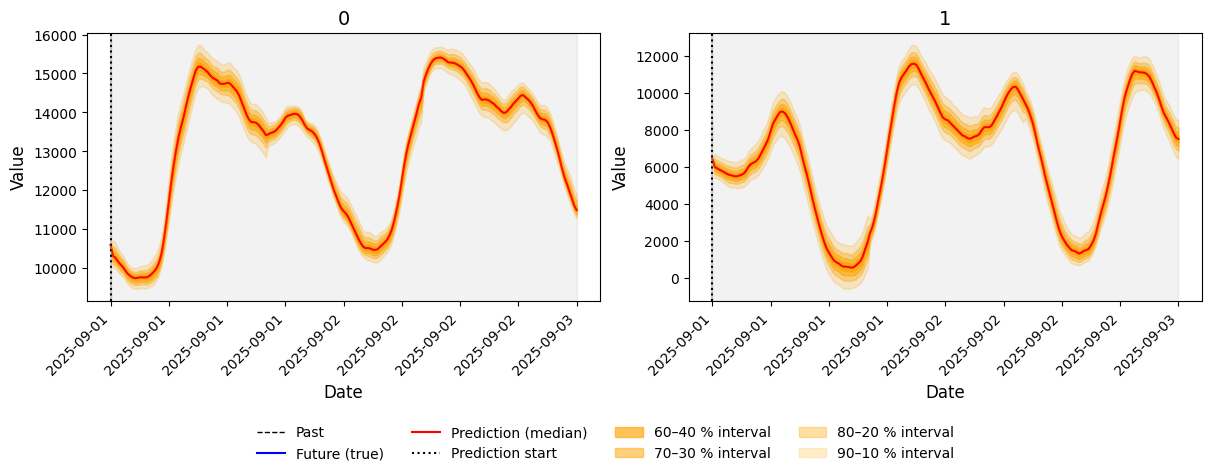

In [11]:
forecasts["Chronos-Bolt-tiny"].plot_forecasts()

In [ ]:
# or convert to autogluon
forecasts["Chronos-Bolt-tiny"].to_AutogluonFormat().head()

mean           0.1           0.2   
item_id timestamp                                                       
0       2025-09-01 00:15:00  10305.457031  10008.364258  10101.958984  \
        2025-09-01 00:30:00  10259.710938   9980.574219  10072.022461   
        2025-09-01 00:45:00  10171.929688   9902.679688   9995.127930   
        2025-09-01 01:00:00  10092.146484   9825.907227   9917.337891   
        2025-09-01 01:15:00  10026.693359   9776.124023   9853.818359   

                                      0.3           0.4           0.5   
item_id timestamp                                                       
0       2025-09-01 00:15:00  10173.560547  10235.219727  10305.457031  \
        2025-09-01 00:30:00  10139.001953  10199.998047  10259.710938   
        2025-09-01 00:45:00  10053.735352  10104.611328  10171.929688   
        2025-09-01 01:00:00   9978.470703  10034.669922  10092.146484   
        2025-09-01 01:15:00   9917.074219   9972.816406  10026.693359   

                                      0.6           0.7           0.8   
item_id timestamp                                                       
0       2025-09-01 00:15:00  10378.813477  10453.540039  10558.461914  \
        2025-09-01 00:30:00  10335.916016  10412.776367  10508.651367   
        2025-09-01 00:45:00  10229.861328  10305.671875  10393.163086   
        2025-09-01 01:00:00  10148.395508  10216.103516  10294.623047   
        2025-09-01 01:15:00  10090.862305  10150.933594  10220.537109   

                                      0.9  
item_id timestamp                          
0       2025-09-01 00:15:00  10702.966797  
        2025-09-01 00:30:00  10641.357422  
        2025-09-01 00:45:00  10518.078125  
        2025-09-01 01:00:00  10401.531250  
        2025-09-01 01:15:00  10325.245117

# Backtesting/Evaluation

In [ ]:
results = pipeline.backtest(data=data,
                            test_start_date=pd.Timestamp("01-01-2023"),
                            rolling_window_eval=False,
                            train=False,
                            val_window_size=None,
                            train_window_size=None,
                            test_window_size=None,
                            calibration_based_on="train",
                            save_results=True)